In [4]:
import os
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import userdata
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

if os.environ["KAGGLE_USERNAME"] is None or os.environ["KAGGLE_KEY"] is None:
    raise ValueError("Please add KAGGLE_USERNAME and KAGGLE_KEY in Colab Secrets.")

print("Kaggle secrets loaded successfully.")


Kaggle secrets loaded successfully.


In [8]:
!kaggle datasets download -d jangedoo/utkface-new -p /content --force


Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:05<00:00, 66.8MB/s]



In [9]:
zip_path = "/content/utkface-new.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [10]:

DATASET_DIR = "/content/utkface_aligned_cropped/UTKFace"

if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError("Dataset folder not found. Please check extraction path.")

print("Total files:", len(os.listdir(DATASET_DIR)))

Total files: 23708


In [12]:
data = []

for filename in os.listdir(DATASET_DIR):
    try:
        parts = filename.split("_")
        age = int(parts[0])
        gender = int(parts[1])
        filepath = os.path.join(DATASET_DIR, filename)
        data.append([filepath, age, gender])
    except Exception:
        continue

df = pd.DataFrame(data, columns=["filepath", "age", "gender"])
print(df.shape)
df.head()


(23708, 3)


,filepath,age,gender
0,/content/utkface_aligned_cropped/UTKFace/28_1_...,28,1
1,/content/utkface_aligned_cropped/UTKFace/31_1_...,31,1
2,/content/utkface_aligned_cropped/UTKFace/2_1_3...,2,1
3,/content/utkface_aligned_cropped/UTKFace/30_0_...,30,0
4,/content/utkface_aligned_cropped/UTKFace/37_0_...,37,0


Age range: 1 to 116
Gender distribution:
gender
0    12391
1    11317
Name: count, dtype: int64


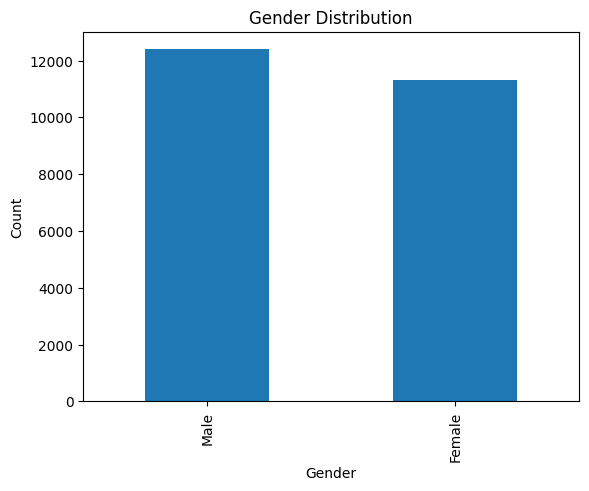

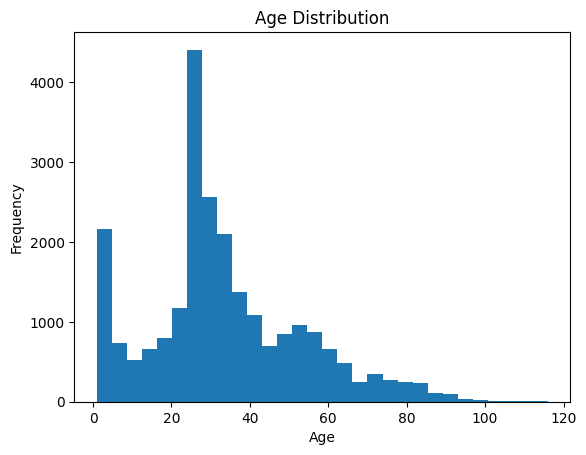

In [13]:
print("Age range:", df["age"].min(), "to", df["age"].max())
print("Gender distribution:")
print(df["gender"].value_counts())

df["gender_name"] = df["gender"].map({0: "Male", 1: "Female"})
df["gender_name"].value_counts().plot(kind="bar", title="Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

df["age"].plot(kind="hist", bins=30, title="Age Distribution")
plt.xlabel("Age")
plt.show()

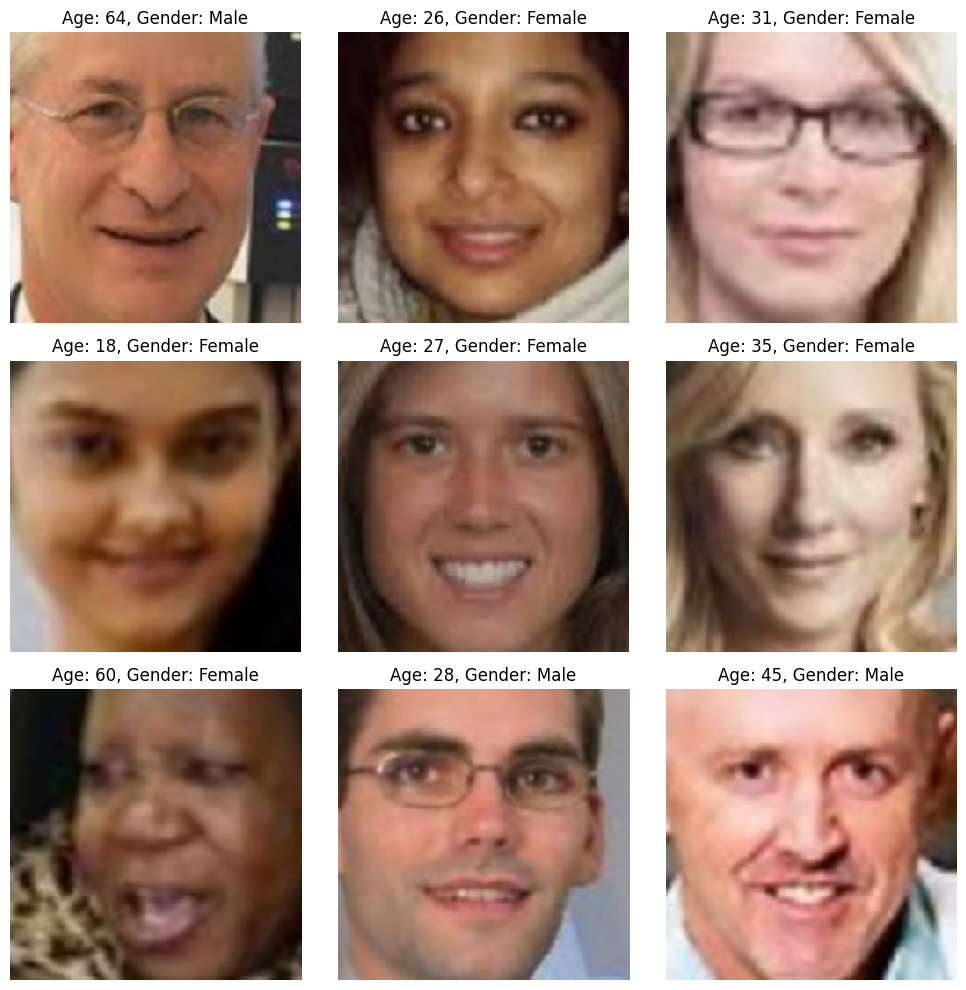

In [14]:
sample_df = df.sample(9, random_state=SEED)
plt.figure(figsize=(10, 10))

for i, row in enumerate(sample_df.itertuples(), 1):
    img = load_img(row.filepath, target_size=(160, 160))
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(f"Age: {row.age}, Gender: {row.gender_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df["gender"])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["gender"])

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

Training samples: 16595
Validation samples: 3556
Testing samples: 3557


In [16]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image_and_labels(filepath, age, gender):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)

    labels = {
        "age_output": tf.cast(age, tf.float32),
        "gender_output": tf.cast(gender, tf.float32)
    }

    return image, labels

In [17]:
def make_dataset(dataframe, shuffle=False):
    filepaths = dataframe["filepath"].values
    ages = dataframe["age"].values
    genders = dataframe["gender"].values

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, ages, genders))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=SEED)

    dataset = dataset.map(load_image_and_labels, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("Datasets created successfully.")

Datasets created successfully.


In [18]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.10)
], name="data_augmentation")

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_tensor=x
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.30)(x)

age_output = Dense(1, activation="linear", name="age_output")(x)
gender_output = Dense(1, activation="sigmoid", name="gender_output")(x)

model = Model(inputs=inputs, outputs=[age_output, gender_output])
model.summary()

/tmp/ipykernel_25623/652772421.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis

 Total params: 2,586,434 (9.87 MB)

 Trainable params: 328,450 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        "age_output": "mae",
        "gender_output": "binary_crossentropy"
    },
    metrics={
        "age_output": ["mae"],
        "gender_output": ["accuracy"]
    },
    loss_weights={
        "age_output": 1.0,
        "gender_output": 5.0
    }
)

In [20]:

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_age_gender_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [21]:

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 979s 2s/step - age_output_loss: 11.0603 - age_output_mae: 11.0609 - gender_output_accuracy: 0.7611 - gender_output_loss: 0.5070 - loss: 13.5969 - val_age_output_loss: 9.2362 - val_age_output_mae: 9.1699 - val_gender_output_accuracy: 0.8290 - val_gender_output_loss: 0.3766 - val_loss: 11.0569
Epoch 2/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 976s 2s/step - age_output_loss: 9.3344 - age_output_mae: 9.3355 - gender_output_accuracy: 0.8039 - gender_output_loss: 0.4245 - loss: 11.4581 - val_age_output_loss: 8.9446 - val_age_output_mae: 8.9117 - val_gender_output_accuracy: 0.8037 - val_gender_output_loss: 0.4133 - val_loss: 10.9858
Epoch 3/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 976s 2s/step - age_output_loss: 9.0828 - age_output_mae: 9.0829 - gender_output_accuracy: 0.8129 - gender_output_loss: 0.4032 - loss: 11.0984 - val_age_output_loss: 8.7459 - val_age_output_mae: 8.7135 - val_gender_output_accuracy: 0.8372 - val_gender_output_loss: 0.3475 - val_loss: 10.4617
Epoch 4/

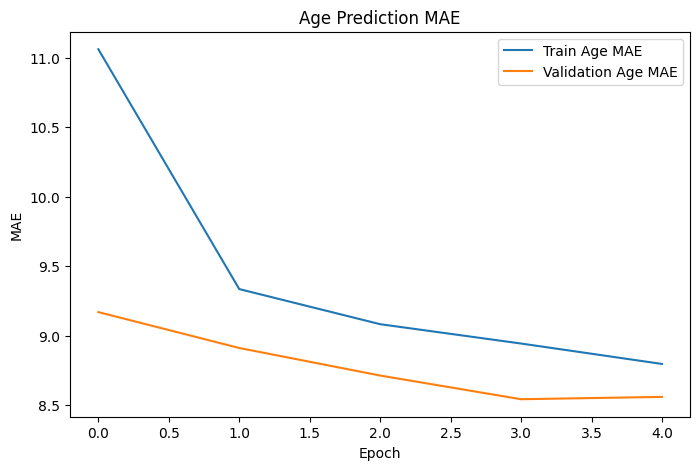

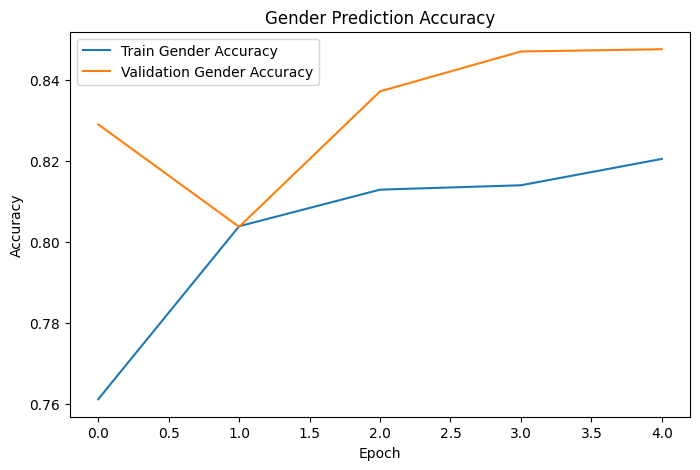

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["age_output_mae"], label="Train Age MAE")
plt.plot(history.history["val_age_output_mae"], label="Validation Age MAE")
plt.title("Age Prediction MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["gender_output_accuracy"], label="Train Gender Accuracy")
plt.plot(history.history["val_gender_output_accuracy"], label="Validation Gender Accuracy")
plt.title("Gender Prediction Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [25]:

test_results = model.evaluate(test_ds)
print(test_results)


112/112 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - age_output_loss: 8.2762 - age_output_mae: 8.2820 - gender_output_accuracy: 0.8400 - gender_output_loss: 0.3467 - loss: 10.0101
[10.010061264038086, 8.276179313659668, 0.34674906730651855, 8.281999588012695, 0.8400337100028992]


In [26]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss={
        "age_output": "mae",
        "gender_output": "binary_crossentropy"
    },
    metrics={
        "age_output": ["mae"],
        "gender_output": ["accuracy"]
    },
    loss_weights={
        "age_output": 1.0,
        "gender_output": 5.0
    }
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 1220s 2s/step - age_output_loss: 10.7200 - age_output_mae: 10.7186 - gender_output_accuracy: 0.7687 - gender_output_loss: 0.4686 - loss: 13.0610 - val_age_output_loss: 9.1918 - val_age_output_mae: 9.1110 - val_gender_output_accuracy: 0.8459 - val_gender_output_loss: 0.3355 - val_loss: 10.7989
Epoch 2/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 1229s 2s/step - age_output_loss: 9.1997 - age_output_mae: 9.2010 - gender_output_accuracy: 0.8133 - gender_output_loss: 0.4036 - loss: 11.2188 - val_age_output_loss: 8.6385 - val_age_output_mae: 8.6113 - val_gender_output_accuracy: 0.8434 - val_gender_output_loss: 0.3422 - val_loss: 10.3323
Epoch 3/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 1214s 2s/step - age_output_loss: 8.6804 - age_output_mae: 8.6772 - gender_output_accuracy: 0.8249 - gender_output_loss: 0.3777 - loss: 10.5655 - val_age_output_loss: 8.2545 - val_age_output_mae: 8.2202 - val_gender_output_accuracy: 0.8504 - val_gender_output_loss: 0.3326 - val_loss: 9.8916
Epoch 

In [27]:

model.save("final_age_gender_prediction_model.keras")
print("Model saved successfully.")


Model saved successfully.


In [28]:

def predict_age_gender(image_path):
    image = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    image_array = img_to_array(image)
    image_array = preprocess_input(image_array)
    image_array = np.expand_dims(image_array, axis=0)

    age_pred, gender_pred = model.predict(image_array)

    predicted_age = round(float(age_pred[0][0]))
    predicted_gender = "Female" if float(gender_pred[0][0]) >= 0.5 else "Male"

    plt.imshow(load_img(image_path))
    plt.axis("off")
    plt.title(f"Predicted Age: {predicted_age}, Gender: {predicted_gender}")
    plt.show()

    return predicted_age, predicted_gender


Actual Age: 23
Actual Gender: Male
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


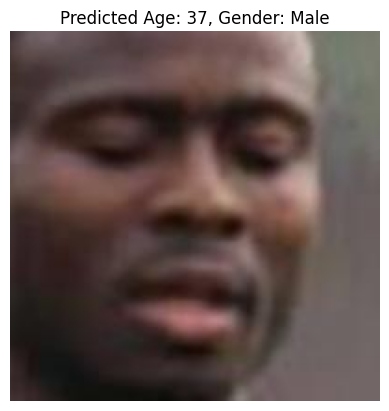

(37, 'Male')

In [29]:
sample = test_df.sample(1, random_state=SEED).iloc[0]
print("Actual Age:", sample["age"])
print("Actual Gender:", "Female" if sample["gender"] == 1 else "Male")

predict_age_gender(sample["filepath"])

Saving girls.png to girls.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


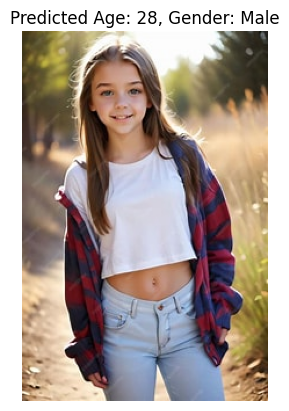

In [32]:

from google.colab import files

uploaded = files.upload()

for uploaded_file in uploaded.keys():
    predict_age_gender(uploaded_file)